In [1]:
import pandas as pd

df_feature_importance = pd.read_csv('../output/Anomaly_delirium/feature_importance/feature_importance_raw.csv')
print(df_feature_importance.shape)

df_feature_importance

(71, 6)


,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen,patient_id
0,-0.012508,3.701126e-03,-0.018247,0.000000e+00,-1.892446e-03,1fbe4
1,-0.007061,-5.494390e-03,-0.002746,0.000000e+00,-3.432917e-03,1fbe4
2,-0.018111,-5.239811e-03,-0.018505,0.000000e+00,-8.558744e-03,1fbe4
3,0.005155,2.684636e-02,0.013451,-3.469447e-18,2.443361e-02,1fbe4
4,-0.002346,9.084980e-03,-0.019136,0.000000e+00,7.515919e-03,1fbe4
...,...,...,...,...,...,...
66,-0.012768,-2.322444e-02,-0.013077,0.000000e+00,-1.467471e-02,c8574
67,0.015665,-3.469447e-18,0.015436,-3.469447e-18,-3.469447e-18,ec812
68,0.029951,6.074757e-02,0.003753,3.469447e-18,4.719856e-02,ec812
69,-0.025345,0.000000e+00,-0.021927,-1.580825e-03,0.000000e+00,ec812


In [10]:
df_filtered = df_feature_importance.groupby("patient_id").filter(lambda x: len(x) > 5)
df_filtered

,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen,patient_id
0,-0.012508,3.701126e-03,-0.018247,0.000000e+00,-1.892446e-03,1fbe4
1,-0.007061,-5.494390e-03,-0.002746,0.000000e+00,-3.432917e-03,1fbe4
2,-0.018111,-5.239811e-03,-0.018505,0.000000e+00,-8.558744e-03,1fbe4
3,0.005155,2.684636e-02,0.013451,-3.469447e-18,2.443361e-02,1fbe4
4,-0.002346,9.084980e-03,-0.019136,0.000000e+00,7.515919e-03,1fbe4
5,-0.037092,-1.483837e-02,-0.018777,0.000000e+00,-1.055682e-02,1fbe4
6,-0.001954,9.909936e-03,0.023040,0.000000e+00,1.774128e-02,1fbe4
7,-0.009801,5.243862e-02,0.004431,0.000000e+00,6.370643e-02,1fbe4
8,-0.002090,4.866228e-02,0.009927,0.000000e+00,5.310314e-02,1fbe4
9,0.000332,3.256210e-03,-0.005267,0.000000e+00,5.768479e-03,1fbe4


In [14]:
df_filtered['patient_id'].value_counts()

30a32    14
1fbe4    13
55cd4     9
c5785     8
c55f8     7
a2849     6
Name: patient_id, dtype: int64

In [26]:
df_importance_long = pd.melt(
    df_filtered,
    id_vars="patient_id",
    value_vars=["entropy_rate", "sleep_quality_score", "early_warning_score", "agitation_counts", "uti_happen"],
    var_name="variable_type",
    value_name="value"
)

# adjust the sign (before adjustment: the negative means that the feature is contributing to the anomaly detection)
df_importance_long['value'] = -df_importance_long['value']
df_importance_long

,patient_id,variable_type,value
0,1fbe4,entropy_rate,1.250828e-02
1,1fbe4,entropy_rate,7.061416e-03
2,1fbe4,entropy_rate,1.811116e-02
3,1fbe4,entropy_rate,-5.154747e-03
4,1fbe4,entropy_rate,2.345527e-03
...,...,...,...
280,c5785,uti_happen,-3.469447e-18
281,c5785,uti_happen,-0.000000e+00
282,c5785,uti_happen,6.938894e-18
283,c5785,uti_happen,-0.000000e+00


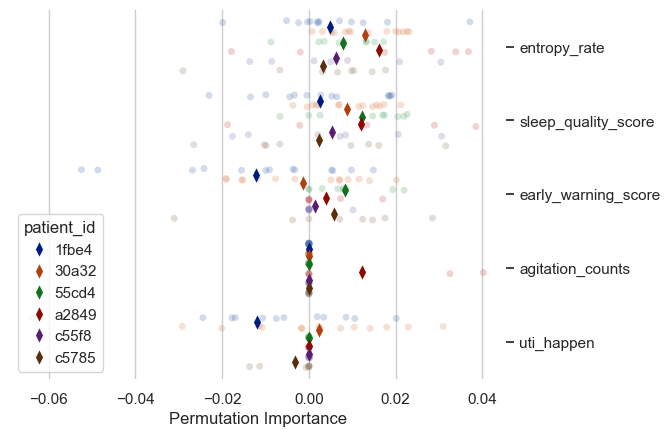

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")

# Initialize the figure
f, ax = plt.subplots()
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.stripplot(
    data=df_importance_long, x="value", y="variable_type", hue="patient_id",
    dodge=True, alpha=.25, zorder=1, legend=False,
)

# Show the conditional means, aligning each pointplot in the
# center of the strips by adjusting the width allotted to each
# category (.8 by default) by the number of hue levels
sns.pointplot(
    data=df_importance_long, x="value", y="variable_type", hue="patient_id",
    dodge=.8 - .8 / 3, palette="dark", errorbar=None,
    markers="d", markersize=4, linestyle="none",
)

# Improve the legend
sns.move_legend(
    ax, loc="lower left", ncol=1, frameon=True, columnspacing=1, handletextpad=0,
)
ax.set_ylabel("")
ax.yaxis.tick_right()
ax.set_xlabel("Permutation Importance")
plt.savefig('../output/Anomaly_delirium/feature_importance/stripplot_importance.png', dpi=300, bbox_inches="tight")